# Lab 01: From Satellite Pixels to LSOA Features

This lab is divided into two connected parts:

1. **From Satellite Pixels to LSOA Features**
2. **Building and comparing IMD deprivation prediction models using satellite-derived features and embeddings**

## Data

- **Landsat 8 surface reflectance imagery** over London (multispectral raster)
- **LSOA boundaries** (Lower Layer Super Output Areas), used as neighbourhood analysis units

## Objectives

By the end of this lab, you should be able to:
- Read and interpret multispectral raster data
- Build neighbourhood-level features by aggregating pixel information to LSOAs
- Explain and compute NDVI from Landsat bands
- Evaluate the effect of spatial coarsening on feature quality

## What We Will Cover

- Inspecting Landsat bands and visual composites (true colour and false colour)
- Loading and understanding LSOA geographies
- Deriving NDVI and simple vegetation classes
- Coarsening imagery and quantifying information loss

#### Workflow:
1. derive pixel-level signals from satellite imagery, then
2. aggregate them to LSOA-level features for later modelling.

In [276]:
#!pip install numpy pandas geopandas xarray regionmask matplotlib # uncomment this to install the required libraries
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

### Satellite imagery

`london_landsat.nc` contains surface reflectance for bands B1–B7 of Landsat 8, reprojected to EPSG:4326. We use the `scipy` engine because the standard `netCDF4` C extension is not available in the WASM kernel.

In [278]:
sr = xr.open_dataset('london_landsat.nc', engine='scipy')['SR']
sr

<xarray.DataArray 'SR' (band: 7, y: 1141, x: 2314)> Size: 148MB
[18481918 values with dtype=float64]
Coordinates:
  * band     (band) object 56B 'B1' 'B2' 'B3' 'B4' 'B5' 'B6' 'B7'
  * y        (y) float64 9kB 51.7 51.7 51.7 51.7 ... 51.28 51.28 51.28 51.27
  * x        (x) float64 19kB -0.5196 -0.5192 -0.5189 ... 0.3434 0.3438 0.3441
Attributes:
    AREA_OR_POINT:  Area

## LSOA boundaries: neighbourhood units for aggregation

LSOAs (Lower Layer Super Output Areas) are small statistical geographies in England and Wales, designed to represent neighbourhood-scale populations.

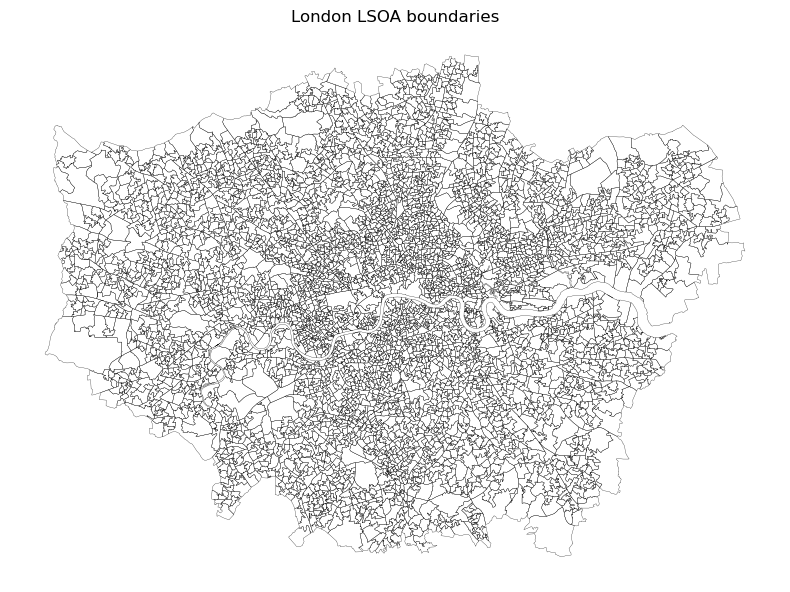

In [280]:
lsoa = geopandas.read_file('uk_lsoa_london_embeds_2020.geojson')[['LSOA21CD', 'geometry']]
fig, ax = plt.subplots(figsize=(8, 8))
lsoa.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.2)
ax.set_title('London LSOA boundaries')
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Exploring individual Landsat bands

Before stacking bands into a colour composite, it is useful to inspect them one by one. Each band captures reflectance in a different part of the spectrum, so the same location can look very different depending on the wavelength we plot.

Here we focus on Bands 2 to 5 because they are the most useful for building visual intuition before computing NDVI:

- **Band 2 (Blue):** water tends to appear dark, while many built surfaces appear brighter.
- **Band 3 (Green):** vegetation becomes easier to distinguish.
- **Band 4 (Red):** vegetation is darker because chlorophyll absorbs red light.
- **Band 5 (NIR):** healthy vegetation is bright because it reflects near-infrared strongly.


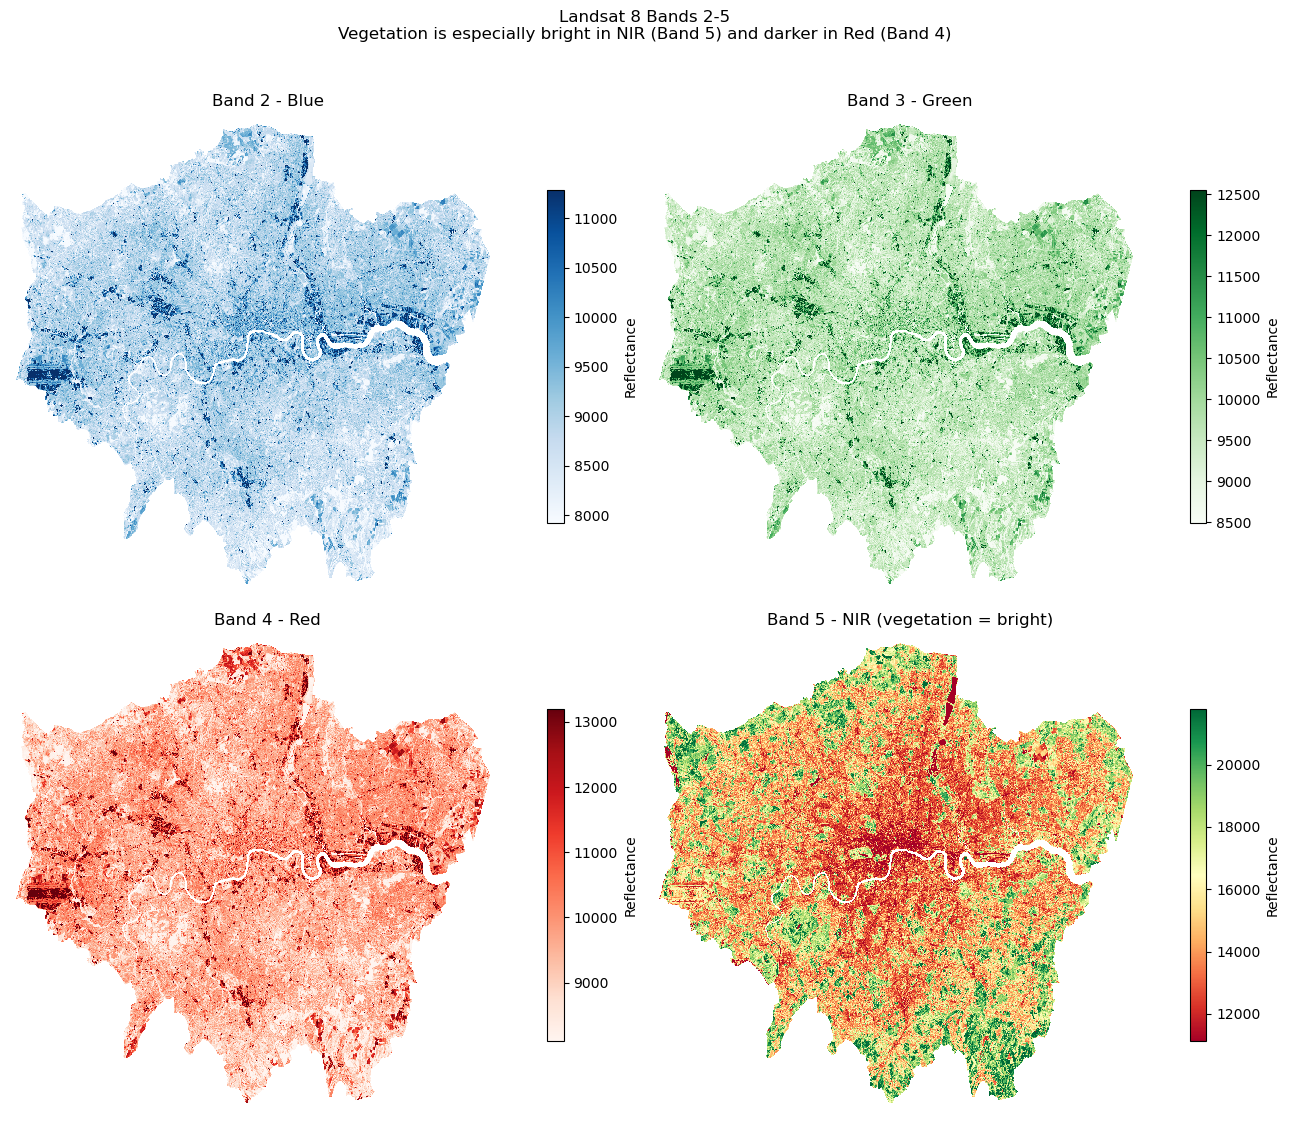

In [282]:
# Plot Bands 2-5 in a 2x2 grid with matched colourmaps
# The percentile stretch makes each band easier to read visually.

BAND_GRID = {
    'B2': ('Blues', 'Band 2 - Blue'),
    'B3': ('Greens', 'Band 3 - Green'),
    'B4': ('Reds', 'Band 4 - Red'),
    'B5': ('RdYlGn', 'Band 5 - NIR (vegetation = bright)'),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, (band_name, (cmap, label)) in zip(axes.flatten(), BAND_GRID.items()):
    band = sr.sel(band=band_name)
    vmin = float(band.quantile(0.02))
    vmax = float(band.quantile(0.98))
    im = band.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(label, fontsize=12)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Reflectance')

plt.suptitle(
    'Landsat 8 Bands 2-5\nVegetation is especially bright in NIR (Band 5) and darker in Red (Band 4)',
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()


## True color view

Individual greyscale bands don't convey much on their own. We stack three bands into an **RGB composite**:

| Composite | Red channel | Green channel | Blue channel | What it shows |
|---|---|---|---|---|
| **True colour** | Band 4 (Red) | Band 3 (Green) | Band 2 (Blue) | How the scene looks to the human eye |
| **False colour (NIR)** | Band 5 (NIR) | Band 4 (Red) | Band 3 (Green) | Vegetation appears **red/pink**; built-up appears **cyan/blue** |

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


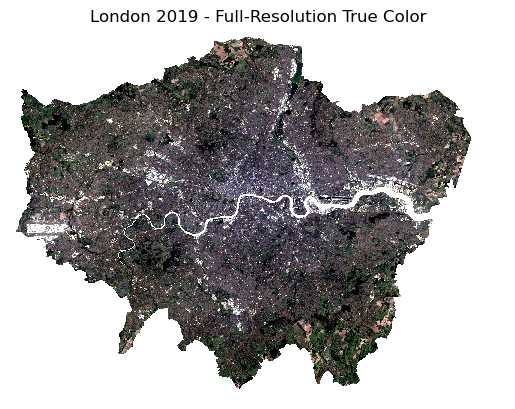

In [285]:
rgb = sr.sel(band=['B4', 'B3', 'B2'])    # <1>
lo = rgb.quantile(0.02, dim=['x', 'y'])  # <2>
hi = rgb.quantile(0.98, dim=['x', 'y'])  # <2>
ax = (
    ((rgb - lo) / (hi - lo))             # <3>
    .clip(0, 1)                          # <4>
    .plot.imshow()                       # <5>
)
ax.axes.set_axis_off()                   # <6>
ax.axes.set_title('London 2019 - Full-Resolution True Color');# <6>
plt.show()                               # <7>

1. Extract red, green, blue bands
2. Identify the 2nd and 98th percentile values
3. Normalise to [0, 1]
4. Clip outliers
5. Display
6. Style the map
7. Explicitly render image

## Area level Landsat statistics

We want one row per LSOA with the mean surface reflectance for each of the 7 bands — a 7-feature vector per area.

Computing this at full resolution (~30 m pixels, 1504 × 1943 grid) is memory-intensive in the browser. We use two approaches:

- **Demo (below):** coarsen the raster 8× before masking — fast enough to run live, slightly less precise
- **Pre-computed (below):** load `landsat_features.csv`, computed offline at full resolution and bundled with the workshop

## Coarsening the raster: simulating lower spatial detail

We coarsen the Landsat grid to examine how reducing spatial detail affects downstream features.

Conceptually:
- **High-resolution features** preserve local variation
- **Coarse features** average across larger areas and may lose fine-grained structure

This sets up a direct comparison of information loss and model sensitivity to spatial resolution.


In [289]:
sr_coarse = sr.coarsen(x=10, y=10, boundary='trim').mean()

Display coarsened:

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


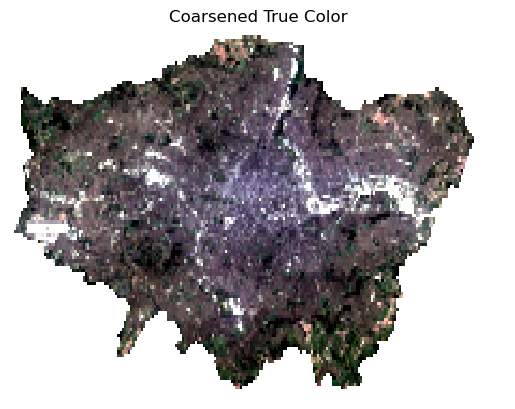

In [296]:
rgb_c = sr_coarse.sel(band=['B4', 'B3', 'B2'])
lo_c = rgb_c.quantile(0.02, dim=['x', 'y'])  
hi_c = rgb_c.quantile(0.98, dim=['x', 'y'])  
ax = (
    ((rgb_c - lo_c) / (hi_c - lo_c))             
    .clip(0, 1)                          
    .plot.imshow()                       
)
ax.axes.set_axis_off()                   
ax.axes.set_title('Coarsened True Color')
plt.show()

Create a mask from the polygons:

In [209]:
mask = regionmask.mask_geopandas(
    lsoa.reset_index(), lon_or_obj=sr_coarse.x, lat=sr_coarse.y, numbers='index'
)

Now we 'clipped' the satellite image (Landsat) to the London LSOA spatial extent.
Next, we obtain the mean values for each satellite band by grouping by polygon (LSOA) and store as a `DataFrame`:

In [211]:
lookup = xr.DataArray(lsoa['LSOA21CD'], dims='mask')
lsoa_bands = sr_coarse.groupby(mask).mean()
coarse_features = (
    lsoa_bands
    .transpose('mask', 'band')
    .assign_coords(LSOA21CD=lookup.sel(mask=lsoa_bands['mask']))
    .swap_dims({'mask': 'LSOA21CD'})
    .to_pandas()
    .rename(columns=lambda c: f"{c.replace('B', 'band_')}_mean")
)

In [212]:
coarse_features.head()

band,band_1_mean,band_2_mean,band_3_mean,band_4_mean,band_5_mean,band_6_mean,band_7_mean
LSOA21CD,,,,,,,
E01000001,8966.640000,9258.050000,9838.020000,9920.495000,11621.940000,11189.960000,10286.865000
E01000002,9054.840000,9402.040000,10033.790000,10178.840000,11514.410000,11217.720000,10201.770000
E01000005,9334.375000,9586.560000,10074.365000,10262.380000,11300.580000,11471.105000,10803.195000
E01000006,9043.180000,9264.775000,9864.355000,10054.790000,13138.710000,12456.925000,11202.825000
E01000008,9323.353269,9644.123563,10438.256825,10474.614404,15472.981501,13372.111351,11445.466056
...,...,...,...,...,...,...,...
E01035718,8835.293636,8903.346364,9577.610000,9404.807273,15827.323636,13282.000000,10744.366364
E01035719,9315.236842,9601.723684,10207.052632,10313.644737,12117.381579,11623.039474,10687.013158
E01035720,9312.350515,9570.350515,10178.412371,10343.762887,12834.597938,11956.762887,10876.536082


### Full-resolution features (pre-computed)

`landsat_features.csv` was computed offline at full ~30m resolution[^1].

[^1]: You can see the full process [here](../../data_prep/lab_00-Data_prep.ipynb).

In [214]:
hires_features = pandas.read_csv('landsat_features.csv', index_col='LSOA21CD')

## Quantifying information loss after coarsening

To measure what is lost when moving from high-resolution to coarse-resolution features, we compare each spectral band at LSOA level.

For each band (for example `B2`, `B3`, `B4`), we match the same LSOA in both tables and compute:
- **Difference**: `coarse - hires` for each LSOA
- **MAE** (Mean Absolute Error): average absolute difference across LSOAs
- **RMSE**: square-root of mean squared difference (penalises larger errors)
- **Bias**: average signed difference (`coarse - hires`)
- **Correlation**: how strongly coarse and hires still co-vary spatially

We then map band-wise differences (`coarse - hires`) and an overall loss score per LSOA, computed as the mean absolute difference across all bands.


           MAE      RMSE  Bias(coarse-hires)    Corr
band                                                
B1     72.3630  111.8760              1.2471  0.9359
B2     84.6924  131.6247              0.6712  0.9292
B3    101.0521  158.8807              2.7049  0.9126
B4    131.0117  198.9454              0.3653  0.9163
B5    325.9171  460.0061             39.6608  0.9424
B6    197.2135  287.1083             20.7269  0.9324
B7    152.7375  230.9965              5.0186  0.8993


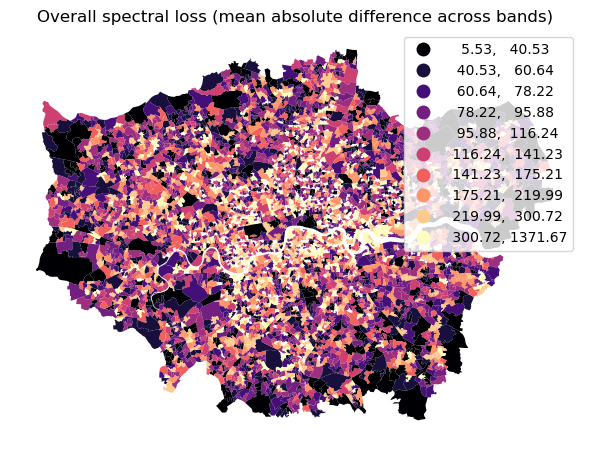

In [216]:
# Compare coarse vs hires with explicit loss metrics and maps
hi = hires_features.copy()
co = coarse_features.copy()

# Ensure LSOA code is index in both tables
if "LSOA21CD" in hi.columns:
     hi = hi.set_index("LSOA21CD")
if "LSOA21CD" in co.columns:
     co = co.set_index("LSOA21CD")

common = hi.index.intersection(co.index)
hi = hi.loc[common]
co = co.loc[common]

bands = [str(b.data) for b in lsoa_bands["band"]]

rows = []
for b in bands:
    c = b.replace("B", "band_") + "_mean"
    d = co[c] - hi[c]
    rows.append({
        "band": b,
        "MAE": d.abs().mean(),
        "RMSE": np.sqrt((d ** 2).mean()),
        "Bias(coarse-hires)": d.mean(),
        "Corr": hi[c].corr(co[c]),
    })

loss_tbl = pd.DataFrame(rows).set_index("band")
print(loss_tbl.round(4))

# plot losses for each band
# fig, axs = plt.subplots(1, len(bands), figsize=(3.8 * len(bands), 4))
# if len(bands) == 1:
#     axs = [axs]

# for ax, b in zip(axs, bands):
#     c = b.replace("B", "band_") + "_mean"
#     diff = (co[c] - hi[c]).rename("diff")
#     g = lsoa.join(diff, on="LSOA21CD")
#     vmax = np.nanpercentile(np.abs(diff), 95)
#     g.plot(column="diff", cmap="RdBu_r", vmin=-vmax, vmax=vmax, ax=ax, legend=True)
#     ax.set_title(f"{b}: coarse - hires")
#     ax.set_axis_off()

# plt.tight_layout()
# plt.show()


absdiff_cols = []
for b in bands:
    c = b.replace("B", "band_") + "_mean"
    colname = f"{c}_absdiff"
    co[colname] = (co[c] - hi[c]).abs()
    absdiff_cols.append(colname)

overall_loss = co[absdiff_cols].mean(axis=1).rename("overall_loss")
lsoa_loss = lsoa.join(overall_loss, on="LSOA21CD")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
lsoa_loss.plot(column="overall_loss", cmap="magma", scheme="quantiles", k=10, legend=True, ax=ax)
ax.set_title("Overall spectral loss (mean absolute difference across bands)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## NDVI (normalised difference vegetation index)

NDVI is a classic vegetation indicator derived from Red and Near-Infrared (NIR) reflectance:

$$\n\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}} = \frac{\text{Band 5} - \text{Band 4}}{\text{Band 5} + \text{Band 4}}\n$$

Why this works: healthy vegetation strongly reflects NIR and absorbs Red light, pushing NDVI upward.

Typical interpretation:
- NDVI < 0: water/cloud/snow-like responses
- NDVI around 0 to 0.2: built-up or bare surfaces
- NDVI around 0.2 to 0.5: sparse vegetation
- NDVI > 0.5: denser healthy vegetation


In [ ]:
# Compute NDVI from the xarray stack called sr

# Select the near infrared band, Band 5, and convert it to float32
nir = sr.sel(band='B5').astype('float32')

# Select the red band, Band 4, and convert it to float32
red = sr.sel(band='B4').astype('float32')

# Ignore divide by zero and invalid value warnings during the NDVI calculation
with np.errstate(divide='ignore', invalid='ignore'):

    # Compute NDVI using the formula:
    # NDVI = (NIR - Red) / (NIR + Red)
    # If NIR + Red equals 0, return NaN to avoid division by zero
    ndvi = xr.where((nir + red) == 0, np.nan, (nir - red) / (nir + red)).astype('float32')

# Print the minimum, maximum, mean NDVI value, ignoring NaN values
print(f"NDVI min: {float(ndvi.min(skipna=True)):.3f}")
print(f"NDVI max: {float(ndvi.max(skipna=True)):.3f}")
print(f"NDVI mean: {float(ndvi.mean(skipna=True)):.3f}")

# Plot the NDVI map using a red to yellow to green colour scale
ax = ndvi.plot.imshow(cmap='RdYlGn', vmin=-0.2, vmax=0.8, figsize=(8,6))

# Add a title to the plot
plt.title('NDVI (Band 5 vs Band 4)')

# Turn off the plot axes
plt.axis('off')

# Display the plot
plt.show()

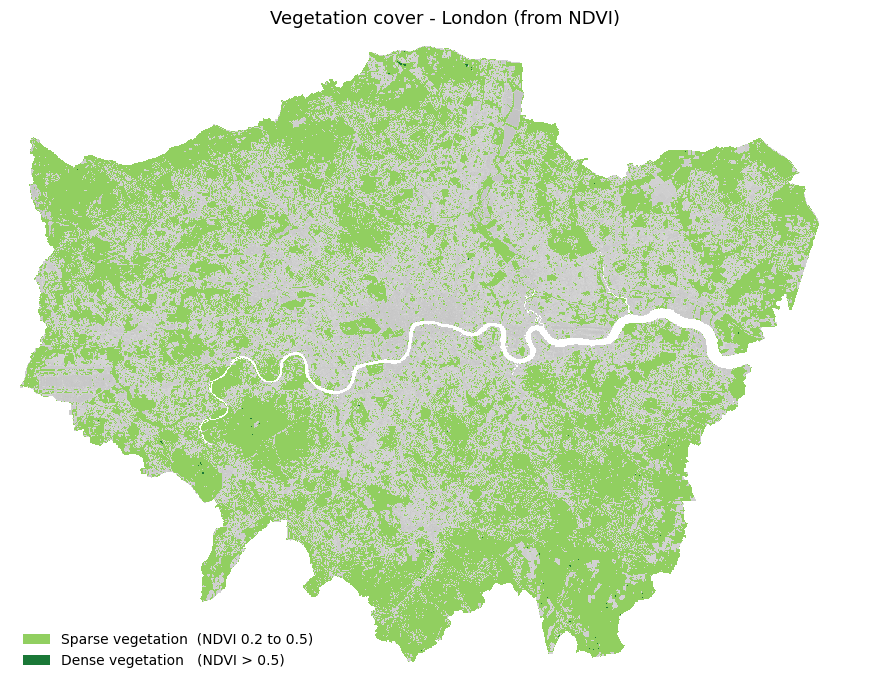

In [311]:
# ── Simple NDVI vegetation map ────────────────────────────────────────────────
# Classify each pixel into two vegetation categories:
#   Sparse vegetation : 0.2 <= NDVI < 0.5
#   Dense vegetation  : NDVI >= 0.5

upper_threshold = 0.5
lower_threshold = 0.2

veg_map = xr.full_like(ndvi, np.nan, dtype="float32")
veg_map = xr.where((ndvi >= lower_threshold) & (ndvi < upper_threshold), 1, veg_map)   # sparse
veg_map = xr.where(ndvi >= upper_threshold, 2, veg_map)                    # dense

cmap_veg = mcolors.ListedColormap(["#91cf60", "#1a7837"])
norm_veg = mcolors.BoundaryNorm([0.5, 1.5, 2.5], cmap_veg.N)

fig, ax = plt.subplots(figsize=(9, 7))

# Base NDVI with geospatial coordinates preserved
ndvi.plot.imshow(
    ax=ax, cmap="Greys_r", vmin=-0.2, vmax=0.8, alpha=0.3,
    add_colorbar=False
)

# Overlay vegetation classes on same coordinates
veg_map.plot.imshow(
    ax=ax, cmap=cmap_veg, norm=norm_veg,
    add_colorbar=False
)

ax.set_title("Vegetation cover - London (from NDVI)", fontsize=13)
ax.set_axis_off()

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(
            facecolor="#91cf60",
            label=f"Sparse vegetation  (NDVI {lower_threshold} to {upper_threshold})"
        ),
        Patch(
            facecolor="#1a7837",
            label=f"Dense vegetation   (NDVI > {upper_threshold})"
        ),
    ],
    loc="lower left", frameon=False, fontsize=10
)

plt.tight_layout()
plt.show()

## Exercise
Let's play with the NDVI thresholds to see how the map changes.

Change: `upper_threshold` and `lower_threshold` in the code above